In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

In [14]:
df=pd.read_csv('datos_limpios.csv')

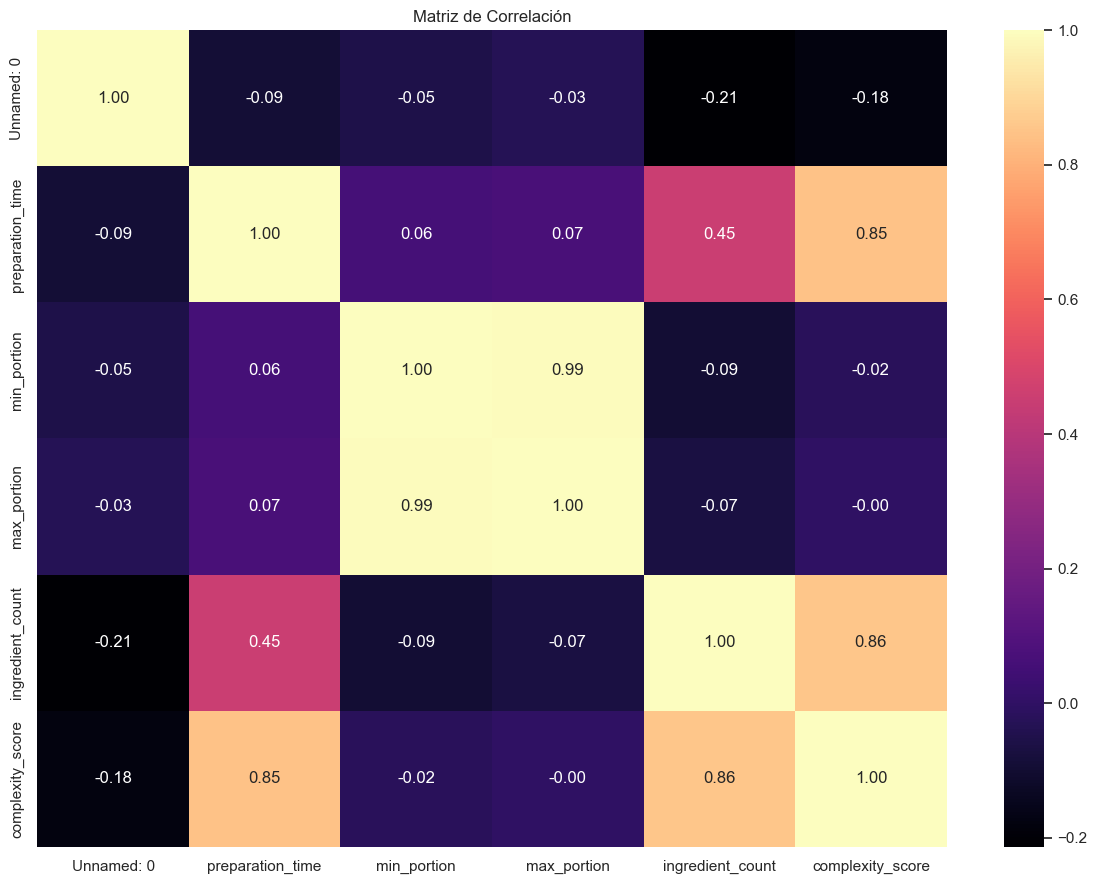

In [15]:
#matriz de correlacion
numeric_df = df.select_dtypes(['int64', 'float64'])
plt.figure(figsize=(12, 9))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='magma',
    fmt=".2f"
)

plt.title('Matriz de Correlación')
plt.tight_layout()
plt.savefig('Matriz.png', dpi=300)

# se detecto una correlacion casi perfecta y lineal entre preparation_time y complexity_score, 
# donde se muestra que el factor tiempo predomina por sobre a la clasificaicon del catalogo, 
# aun asi, este no llega a ser 1.0 debido a la friccion otorgada por ingredient_count, 
# validando asi estadisticamente la muestra metrica compuesta, aportando informacion y sin 
# ser una variable redundante.

# tambien tenemos una correlacion entre el preparation_time y ingredient_count, donde es muy 
# baja o cerca al 0, nos indica que para el negocio, un plato con muchos ingredientes no 
# necesariamente requiere mucho tiempo de coccion.

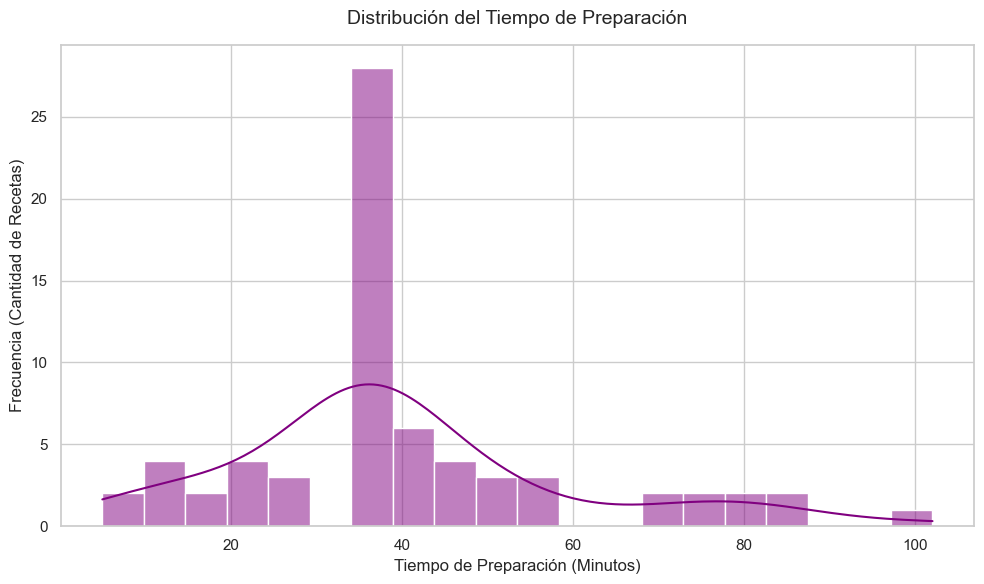

In [16]:
#histograma
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df, x='preparation_time', bins=20, kde=True, color='purple', ax=ax)
ax.set_title('Distribución del Tiempo de Preparación', fontsize=14, pad=15)
ax.set_xlabel('Tiempo de Preparación (Minutos)', fontsize=12)
ax.set_ylabel('Frecuencia (Cantidad de Recetas)', fontsize=12)

plt.tight_layout()
plt.savefig('histograma.png', dpi=300)
plt.show()

# gracias al histograma podemos observar que la mayor densidad de las recetas estan 
# por debajo de 60 minutos indicando que el catalogo tiene en su mayoria recetas de 
# duracion no mas de una hora, sin embargo si existen recetas cuyo tiempo de praparacion 
# son de mas de los 60 minutos

C:\Users\leito\AppData\Local\Temp\ipykernel_6388\229974154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


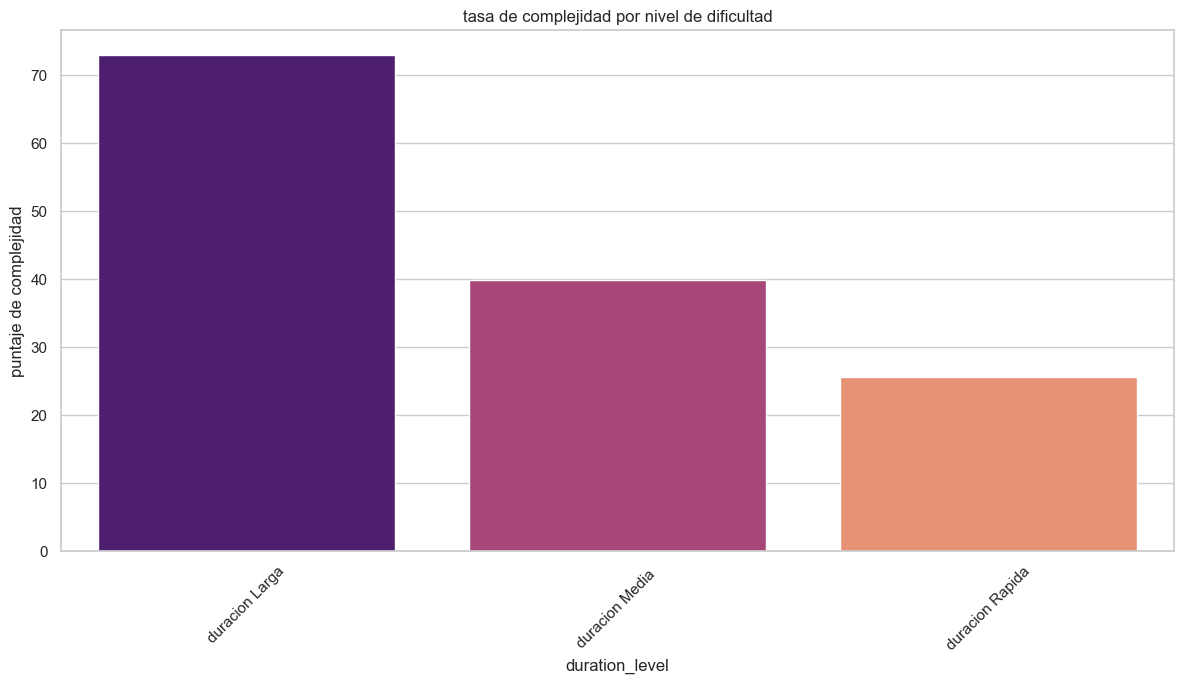

In [17]:
#barras
plt.figure(figsize=(12, 7))
rate=df.groupby('duration_level')['complexity_score'].median().reset_index()
sns.barplot(
    data=rate,
    x='duration_level',
    y='complexity_score',
    palette='magma'
)
plt.title('tasa de complejidad por nivel de dificultad')
plt.ylabel('puntaje de complejidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('barplot.png', dpi=300)
plt.show()

# Al examinar el gráfico de barras, se confirma que las recetas con mayor nivel 
# de complejidad media se encuentran dentro de la categoría de duración "Larga", 
# mientras que las de menor puntuación pertenecen a las "Rápidas". Este patrón 
# lineal proporciona un diagnóstico esencial: valida de forma estadística que la 
# segmentación por tiempo efectuada en el ETL es coherente y actúa como un indicador 
# fiable del esfuerzo técnico total de la receta. Esto refleja la realidad del 
# proceso de cocción, permitiendo que los algoritmos de recomendación ofrezcan 
# sugerencias precisas y reduzcan la tasa de abandono de los usuarios al cocinar.

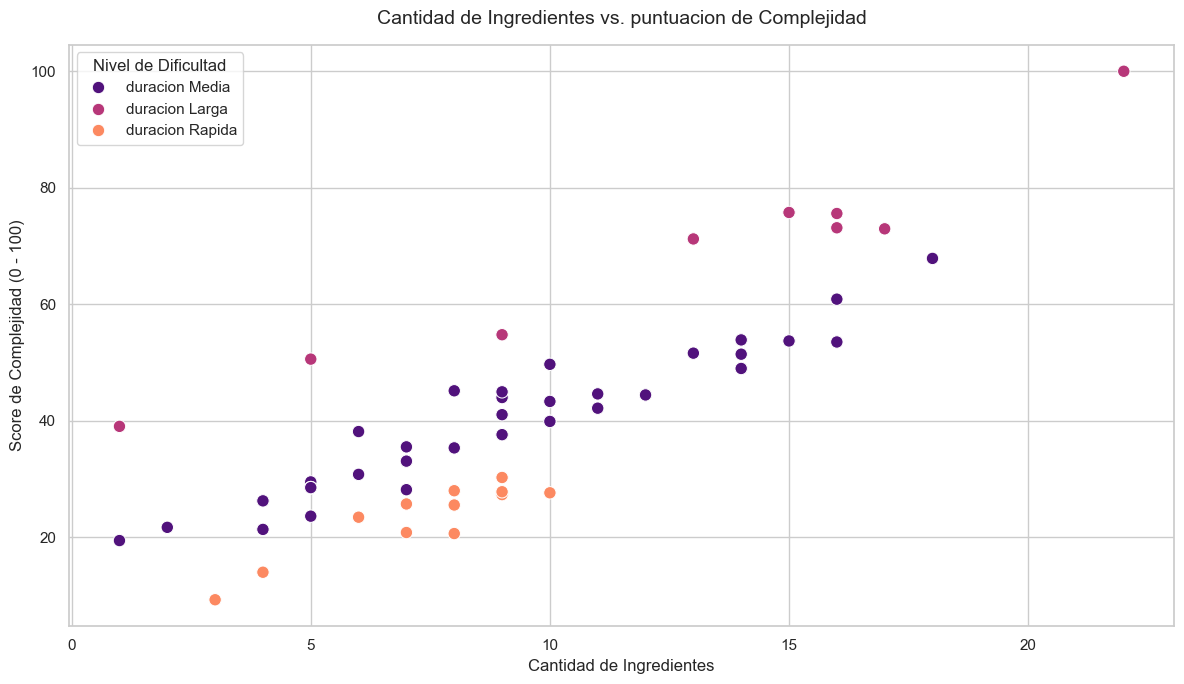

In [18]:
#scatterplot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(data=df, x='ingredient_count', y='complexity_score', hue='duration_level', palette='magma', s=80, ax=ax)
ax.set_title('Cantidad de Ingredientes vs. puntuacion de Complejidad', fontsize=14, pad=15)
ax.set_xlabel('Cantidad de Ingredientes', fontsize=12)
ax.set_ylabel('Score de Complejidad (0 - 100)', fontsize=12)
ax.legend(title='Nivel de Dificultad')

plt.tight_layout()
plt.savefig('dispercion.png', dpi=300)
plt.show()

#analizando el gráfico de dispersión se observa una clara tendencia ascendente 
# dispersa que muestra la relación entre la cantidad de ingredientes y el puntaje 
# de complejidad, donde la distribución de colores por nivel de duración segmenta 
# el mapa de manera estratificada. revelando el impacto directo a la fórmula 
# compuesta creada en el ETL, donde las recetas se separan verticalmente de forma 
# nítida según su duración, lo que demuestra que el factor tiempo actúa como 
# el principal vector de desplazamiento en el puntaje. este patrón visual confirma 
# que no existen solapamientos críticos o incongruencias en los datos, validando 
# que el catálogo interactúa de forma predecible y permitiendo que los modelos 
# predictivos posteriores (como segmentaciones o clasificaciones) discriminen con 
# total precisión los perfiles de recetas para recomendarlas eficientemente a los 
# usuarios según sus recursos de tiempo y despensa.

In [20]:
df.to_csv('datos_limpios_conKDD.csv')
df.to_excel('datos_limpios_conKDD.xlsx')

